# 🛡️ GTM Engineer Job Market Analysis (March 2026)

This notebook provides a deep dive into the GTM (Go-To-Market) Engineering job market. We analyze 310 high-quality technical roles extracted from Builtin.com across major tech hubs.

---

## ⚙️ Section 0: Setup and Data Loading
Loading libraries, setting the premium dark theme, and importing the structured dataset.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from IPython.display import display, Markdown

# Premium Aesthetics
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
sns.set_context("notebook", font_scale=1.2)

# Setup chart directory
CHART_DIR = "_internal/charts"
if not os.path.exists(CHART_DIR):
    os.makedirs(CHART_DIR)

# Load Structured Data
DATA_PATH = "_internal/structured_jobs.json"
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    df = pd.DataFrame(raw_data)

display(Markdown(f"### ✅ Data successfully loaded: {len(df)} total records analyzed."))

### ✅ Data successfully loaded: 829 total records analyzed.

## 📊 Section 1: Dataset Overview
High-level view of GTM Technical roles.

In [ ]:
df_gtm = df[df["is_gtm_technical"] == True].copy()
top_companies = df_gtm['company'].value_counts().head(10).reset_index()
top_companies.columns = ['Company', 'Job Count']

In [ ]:
df_gtm.info()

In [14]:
# create table Top 10 Companies Hiring GTM Engineers

from IPython.display import display, Markdown
display(Markdown("### 🏢 Top 10 Companies Hiring GTM Engineers"))
display(top_companies.style.background_gradient(cmap='cool', subset=['Job Count']))

### 🏢 Top 10 Companies Hiring GTM Engineers

,Company,Job Count
0,OpenAI,4
1,Klaviyo,4
2,Rain,3
3,Lucid Software,3
4,Liberty Mutual Insurance,3
5,Airwallex,3
6,Veeva,3
7,SoFi,3
8,General Motors,3
9,FreeWheel,3


## 🧪 Section 2: Job Type Distribution

In [7]:
dist = df['is_gtm_technical'].value_counts().reset_index()
dist.columns = ['Category', 'Count']
dist['Percentage'] = (dist['Count'] / dist['Count'].sum() * 100).round(1).astype(str) + '%'
dist['Category'] = dist['Category'].map({True: '🛡️ GTM Technical', False: '☁️ Other Tech Roles'})

from IPython.display import display, Markdown
display(Markdown("### 🧪 GTM Technical Role Distribution"))
display(dist.style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])]))

### 🧪 GTM Technical Role Distribution

,Category,Count,Percentage
0,☁️ Other Tech Roles,519,62.6%
1,🛡️ GTM Technical,310,37.4%


## 💰 Section 3: Compensation Analysis

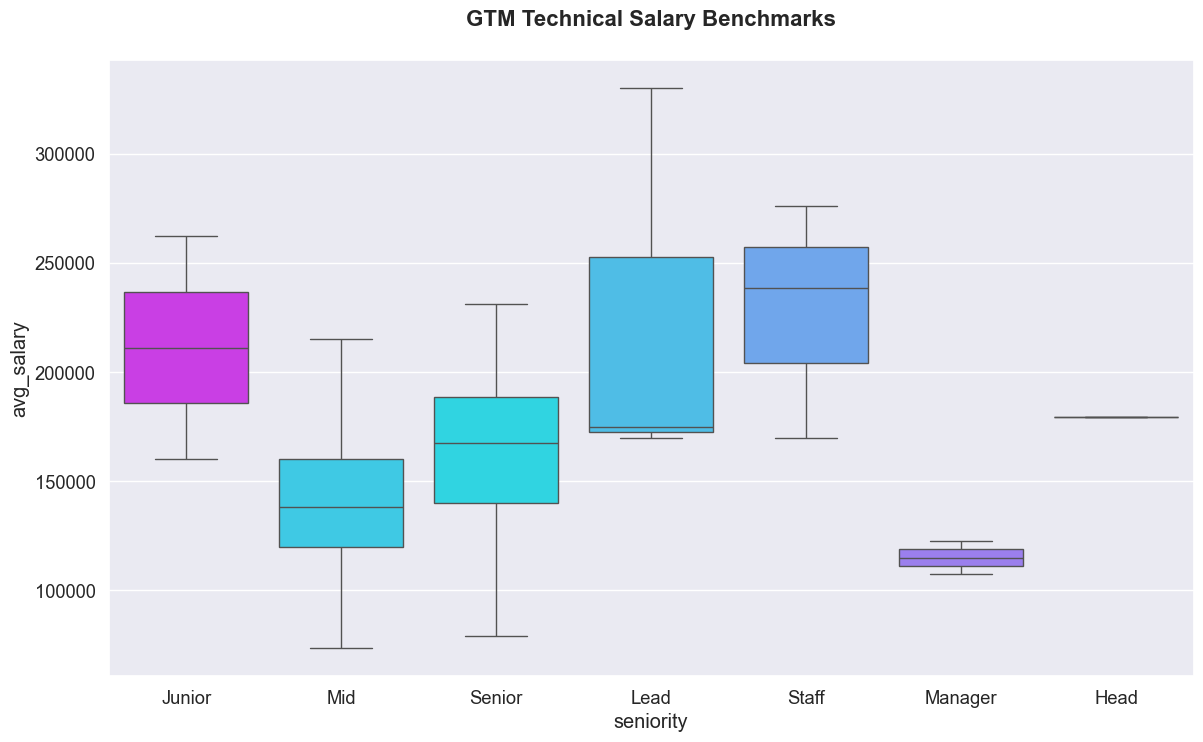

In [8]:
df_gtm["avg_salary"] = (pd.to_numeric(df_gtm["salary_min"], errors='coerce') + pd.to_numeric(df_gtm["salary_max"], errors='coerce')) / 2
sal_df = df_gtm.dropna(subset=["avg_salary", "seniority"])
sal_df = sal_df[sal_df["avg_salary"] > 1000]
order = ["Junior", "Mid", "Senior", "Lead", "Staff", "Manager", "Head"]
current_order = [o for o in order if o in sal_df["seniority"].unique()]

plt.figure(figsize=(14, 8))
sns.boxplot(data=sal_df, x="seniority", y="avg_salary", order=current_order, hue="seniority", palette="cool", legend=False)
plt.title("GTM Technical Salary Benchmarks", fontsize=16, fontweight='bold', pad=25)
plt.savefig(os.path.join(CHART_DIR, "03_compensation_analysis.png"), bbox_inches='tight', dpi=300)
plt.show()

## 📍 Section 4: Location & Remote Trends
Analyzing where the GTM Engineering talent is needed and the prevalence of remote work.

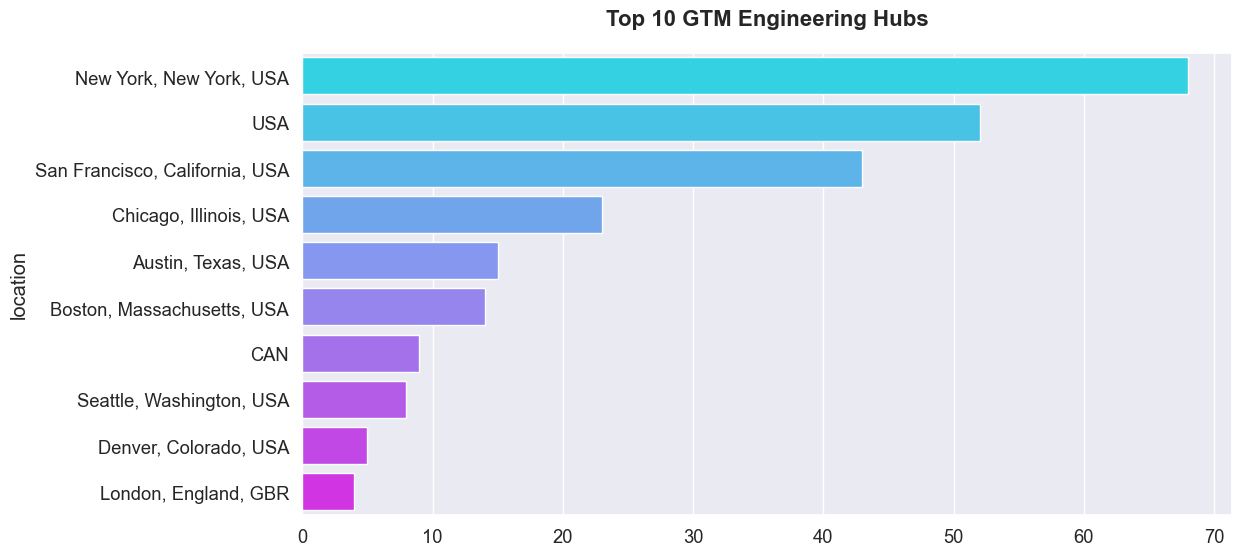

**Remote Availability:** 1 roles (0.3%) mention Remote options.

In [9]:
# Location Breakdown
top_locs = df_gtm['location'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locs.values, y=top_locs.index, hue=top_locs.index, palette="cool", legend=False)
plt.title("Top 10 GTM Engineering Hubs", fontsize=16, weight='bold', pad=20)
plt.savefig(os.path.join(CHART_DIR, "04_location_remote.png"), bbox_inches='tight', dpi=300)
plt.show()

# Remote analysis (simple count of 'Remote' in location)
remote_count = df_gtm['location'].str.contains('Remote', case=False, na=False).sum()
display(Markdown(f"**Remote Availability:** {remote_count} roles ({(remote_count/len(df_gtm))*100:.1f}%) mention Remote options."))

## 🛠️ Section 5: Tech Stack Deep-Dive
Identifying the most popular tools in the GTM Engineering ecosystems.

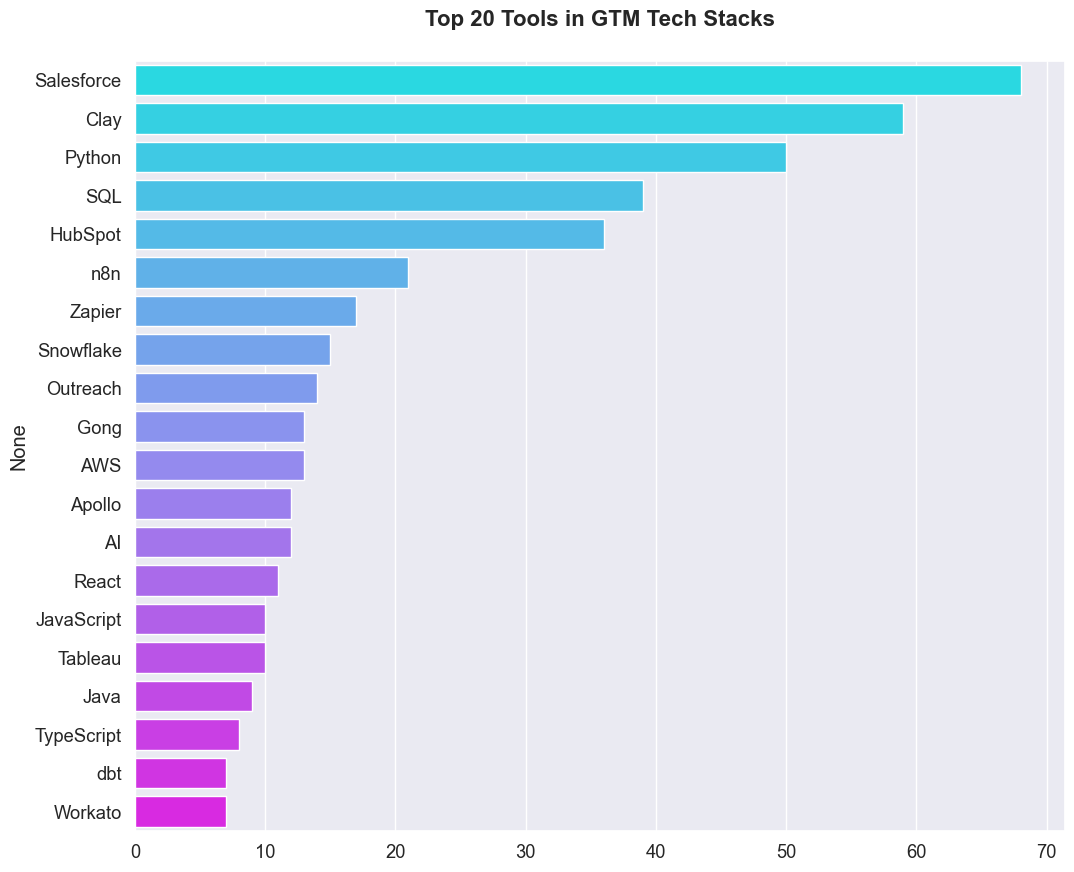

In [12]:
all_tools = []
for tools in df_gtm["tech_stack"].dropna():
    if isinstance(tools, list): all_tools.extend(tools)
tool_counts = pd.Series(all_tools).value_counts().head(20)

plt.figure(figsize=(12, 10))
sns.barplot(x=tool_counts.values, y=tool_counts.index, hue=tool_counts.index, palette="cool", legend=False)
plt.title("Top 20 Tools in GTM Tech Stacks", fontsize=16, fontweight='bold', pad=25)
plt.savefig(os.path.join(CHART_DIR, "05_top_tools.png"), bbox_inches='tight', dpi=300)
plt.show()

## 💻 Section 6: Programming Languages
What coding skills are required for 'Technical' GTM roles?

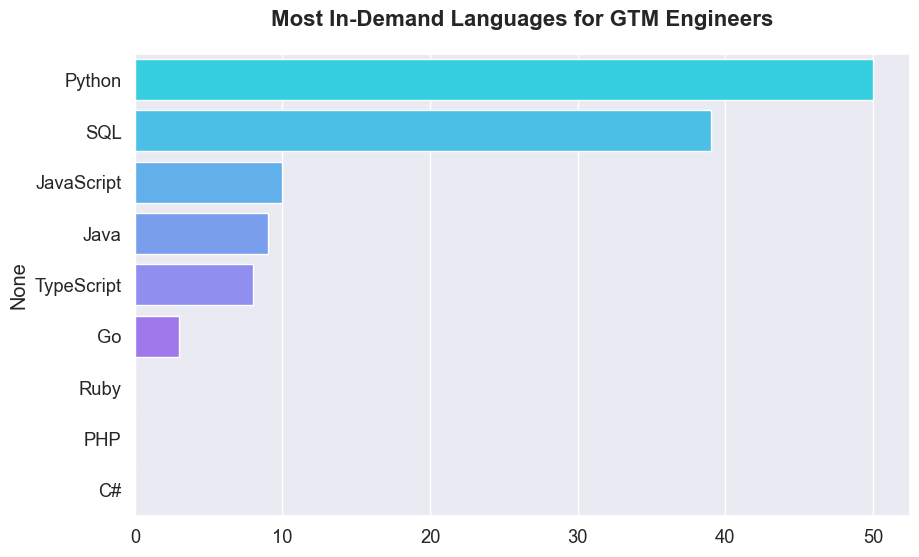

In [13]:
target_langs = ['Python', 'JavaScript', 'TypeScript', 'SQL', 'Java', 'Ruby', 'Go', 'PHP', 'C#']
lang_counts = {lang: 0 for lang in target_langs}
for tools in df_gtm["tech_stack"].dropna():
    if isinstance(tools, list):
        for t in tools:
            if t in lang_counts: lang_counts[t] += 1

lang_df = pd.Series(lang_counts).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=lang_df.values, y=lang_df.index, hue=lang_df.index, palette="cool", legend=False)
plt.title("Most In-Demand Languages for GTM Engineers", fontsize=16, fontweight='bold', pad=20)
plt.savefig(os.path.join(CHART_DIR, "08_languages.png"), bbox_inches='tight', dpi=300)
plt.show()

In [27]:
# THE END